# Example: Unfolding methods without a dedicated notebook

This notebook demonstrates how to import **and actually run** every unfolding method in `bssunfold`.

The methods covered here are:

| Public method | Notes |
|---|---|
| `unfold_amaxed_regularization` | AMAXED with automatic regularization |
| `unfold_crystal_ball` | Crystal-ball peak model |
| `unfold_directed_divergence` | I-divergence iteration (BON95 refinement core) |
| `unfold_express` | Piecewise-exponential Express model |
| `unfold_ferdor` | FERDOR, discrepancy-principle smoothing |
| `unfold_imaxed` | IMAXED (iterated MAXED) |
| `unfold_iterative_refinement` | Iterative residual refinement |
| `unfold_maeo` | MAEO ensemble optimization *(needs pymoo)* |
| `unfold_nsduaz` | NSDUAZ catalogue selection |
| `unfold_odl_pdhg` | PDHG via ODL *(needs odl)* |
| `unfold_odl_douglas_rachford` | Douglas-Rachford via ODL *(needs odl)* |
| `unfold_qubo` | QUBO quantum-inspired annealing *(needs pyqubo/dwave-neal)* |
| `unfold_rebunki` | ReBUNKI / SPUNIT |
| `unfold_rfsp_jul` | RFSP Julich |
| `unfold_scipy_direct_method` | Direct scipy solver |
| `unfold_staysl` | STAYSL |
| `unfold_tikhonov_legendre` | Tikhonov on Legendre basis |
| `unfold_zfit` | Bayesian unfolding via zfit *(needs zfit)* |
| `unfold_ensemble` | Stacked ensemble of base methods |
| `unfold_mystic_hybrid` | Mystic hybrid objective |


In [8]:
import numpy as np
import pandas as pd
import traceback

import matplotlib.pyplot as plt
from bssunfold import Detector, RF_LANL
from bssunfold.utils.plotting import plot_comparison

%matplotlib inline

# Load IAEA reference spectra (relative path — notebooks live in examples/)
reference_spectrum = pd.read_csv('../tests/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv')

# Build a detector from the LANL response functions
det = Detector(RF_LANL)
readings = det.get_effective_readings_for_spectra(
    reference_spectrum[['E_MeV', 'ISO_ref_Cf252']]
)

print('Energy bins:', det.n_energy_bins)
print('Detectors:', det.detector_names)
print('Readings sample:', {k: round(v, 4) for k, v in list(readings.items())[:4]})

Energy bins: 60
Detectors: ['3in', '4in', '5in', '6in', '8in', '9in', '12in', '18in', '9inPb', '12inPb', '18inPb']
Readings sample: {'3in': 0.3399, '4in': 1.154, '5in': 1.695, '6in': 2.4149}


## Shared runner

The helper below runs any `unfold_*` method, stores the result (or error) in `RESULTS`, and prints a one-line status. Methods that need optional dependencies (`odl`, `zfit`, `pyqubo`, `pymoo`) raise inside the runner and are reported as `FAIL` instead of aborting the notebook.

The runner also **zeroes the first and last energy bins** of every successful spectrum: residual flux at the grid ends is an unphysical edge artefact (a runaway peak), so it is removed before storing/plotting the result.

In [9]:
RESULTS = {}

def run_unfold(name, **kw):
    """Run det.unfold_<name>(readings, save_result=False, **kw), record and report."""
    fn = getattr(det, f'unfold_{name}', None)
    if fn is None:
        RESULTS[name] = ('error', f'Detector has no unfold_{name}')
        print(f'[{name}] SKIP  no Detector method')
        return None
    try:
        res = fn(readings, save_result=False, **kw)
        # Zero the first and last energy bins: any residual there is an
        # unphysical edge artefact (e.g. runaway flux at the grid ends).
        spec = np.asarray(res.get('spectrum')).copy()
        if spec.ndim == 1 and spec.size >= 2:
            spec[0] = 0.0
            spec[-1] = 0.0
        res['spectrum'] = spec
        RESULTS[name] = ('ok', res)
        print(f'[{name}] OK   spectrum={spec.shape}  max={spec.max():.3e}')
        return res
    except Exception as exc:
        RESULTS[name] = ('error', f'{type(exc).__name__}: {exc}')
        print(f'[{name}] FAIL {type(exc).__name__}: {exc}')
        return None

## Standard methods (no extra dependencies)

In [10]:
run_unfold('amaxed_regularization')
# run_unfold('odl_pdhg') # ODL PDHG — needs odl
run_unfold('crystal_ball')
run_unfold('directed_divergence')
run_unfold('express')
run_unfold('ferdor')
run_unfold('imaxed')
# run_unfold('iterative_refinement')
# run_unfold('maeo', n_cycles=2, n_gen_per_cycle=3, pop_size=20, seed=0)
run_unfold('nsduaz')
run_unfold('odl_douglas_rachford') # ODL Douglas-Rachford — needs odl
run_unfold('qubo') # QUBO quantum-inspired annealing — needs pyqubo/dwave-neal
run_unfold('rebunki')
run_unfold('rfsp_jul')
run_unfold('scipy_direct_method')
run_unfold('mystic_hybrid')
run_unfold('ensemble')
run_unfold('tikhonov_legendre')
run_unfold('staysl')

[amaxed_regularization] OK   spectrum=(60,)  max=4.361e-01
[crystal_ball] OK   spectrum=(60,)  max=4.225e-01
[directed_divergence] OK   spectrum=(60,)  max=3.903e-01
[express] OK   spectrum=(60,)  max=6.736e-01
[ferdor] OK   spectrum=(60,)  max=4.342e-01
[imaxed] OK   spectrum=(60,)  max=4.755e-01
[nsduaz] OK   spectrum=(60,)  max=1.320e+00
[odl_douglas_rachford] OK   spectrum=(60,)  max=1.110e-01
[qubo] OK   spectrum=(60,)  max=4.844e-01
[rebunki] OK   spectrum=(60,)  max=1.187e+00
[rfsp_jul] OK   spectrum=(60,)  max=9.725e-01
[scipy_direct_method] OK   spectrum=(60,)  max=4.225e-01
[mystic_hybrid] OK   spectrum=(60,)  max=6.147e-01
[ensemble] OK   spectrum=(60,)  max=4.304e-01
[tikhonov_legendre] OK   spectrum=(60,)  max=3.843e-01
[staysl] OK   spectrum=(60,)  max=6.819e-01


{'energy': array([1.00000000e-09, 1.58489319e-09, 2.51188643e-09, 3.98107171e-09,
        6.30957344e-09, 1.00000000e-08, 1.58489319e-08, 2.51188643e-08,
        3.98107171e-08, 6.30957344e-08, 1.00000000e-07, 1.58489319e-07,
        2.51188643e-07, 3.98107171e-07, 6.30957344e-07, 1.00000000e-06,
        1.58489319e-06, 2.51188643e-06, 3.98107171e-06, 6.30957344e-06,
        1.00000000e-05, 1.58489319e-05, 2.51188643e-05, 3.98107171e-05,
        6.30957344e-05, 1.00000000e-04, 1.58489319e-04, 2.51188643e-04,
        3.98107171e-04, 6.30957344e-04, 1.00000000e-03, 1.58489319e-03,
        2.51188643e-03, 3.98107171e-03, 6.30957344e-03, 1.00000000e-02,
        1.58489319e-02, 2.51188643e-02, 3.98107171e-02, 6.30957344e-02,
        1.00000000e-01, 1.58489319e-01, 2.51188643e-01, 3.98107171e-01,
        6.30957344e-01, 1.00000000e+00, 1.58489319e+00, 2.51188643e+00,
        3.98107171e+00, 6.30957344e+00, 1.00000000e+01, 1.58489319e+01,
        2.51188643e+01, 3.98107171e+01, 6.30957344e+01

## Comparison of reconstructed spectra

In [11]:
ok_results = {name: res for name, (status, res) in RESULTS.items() if status == 'ok'}
print('Successful methods:', len(ok_results))
print('Failed/skipped:', [name for name, (st, _) in RESULTS.items() if st != 'ok'])

Successful methods: 16
Failed/skipped: []


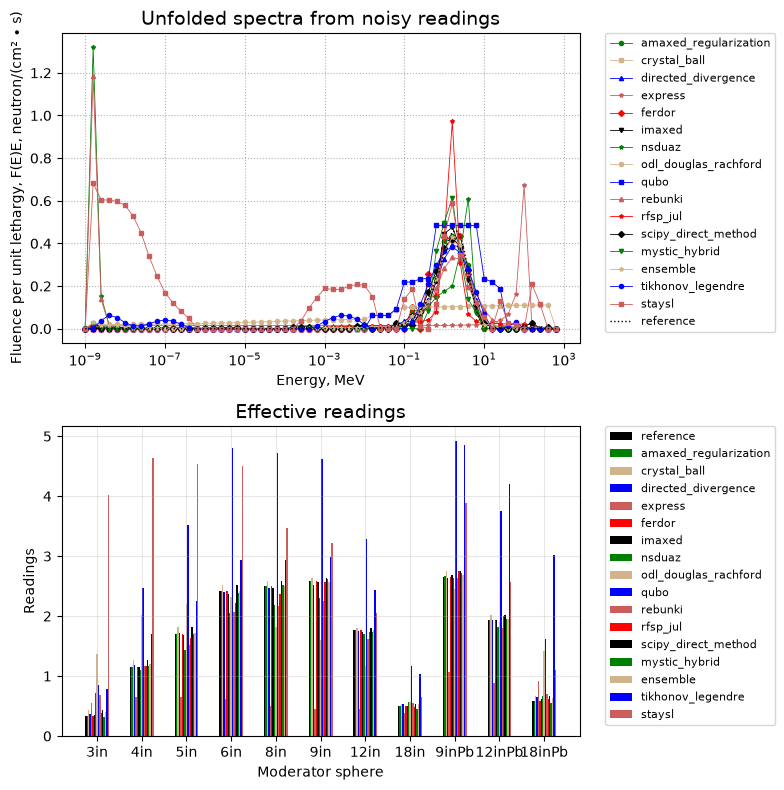

In [12]:
if ok_results:
    fig, ax = plot_comparison(
        results=ok_results,
        readings=readings,
        reference_spectrum=reference_spectrum[['E_MeV', 'ISO_ref_Cf252']],
    )
    plt.show()

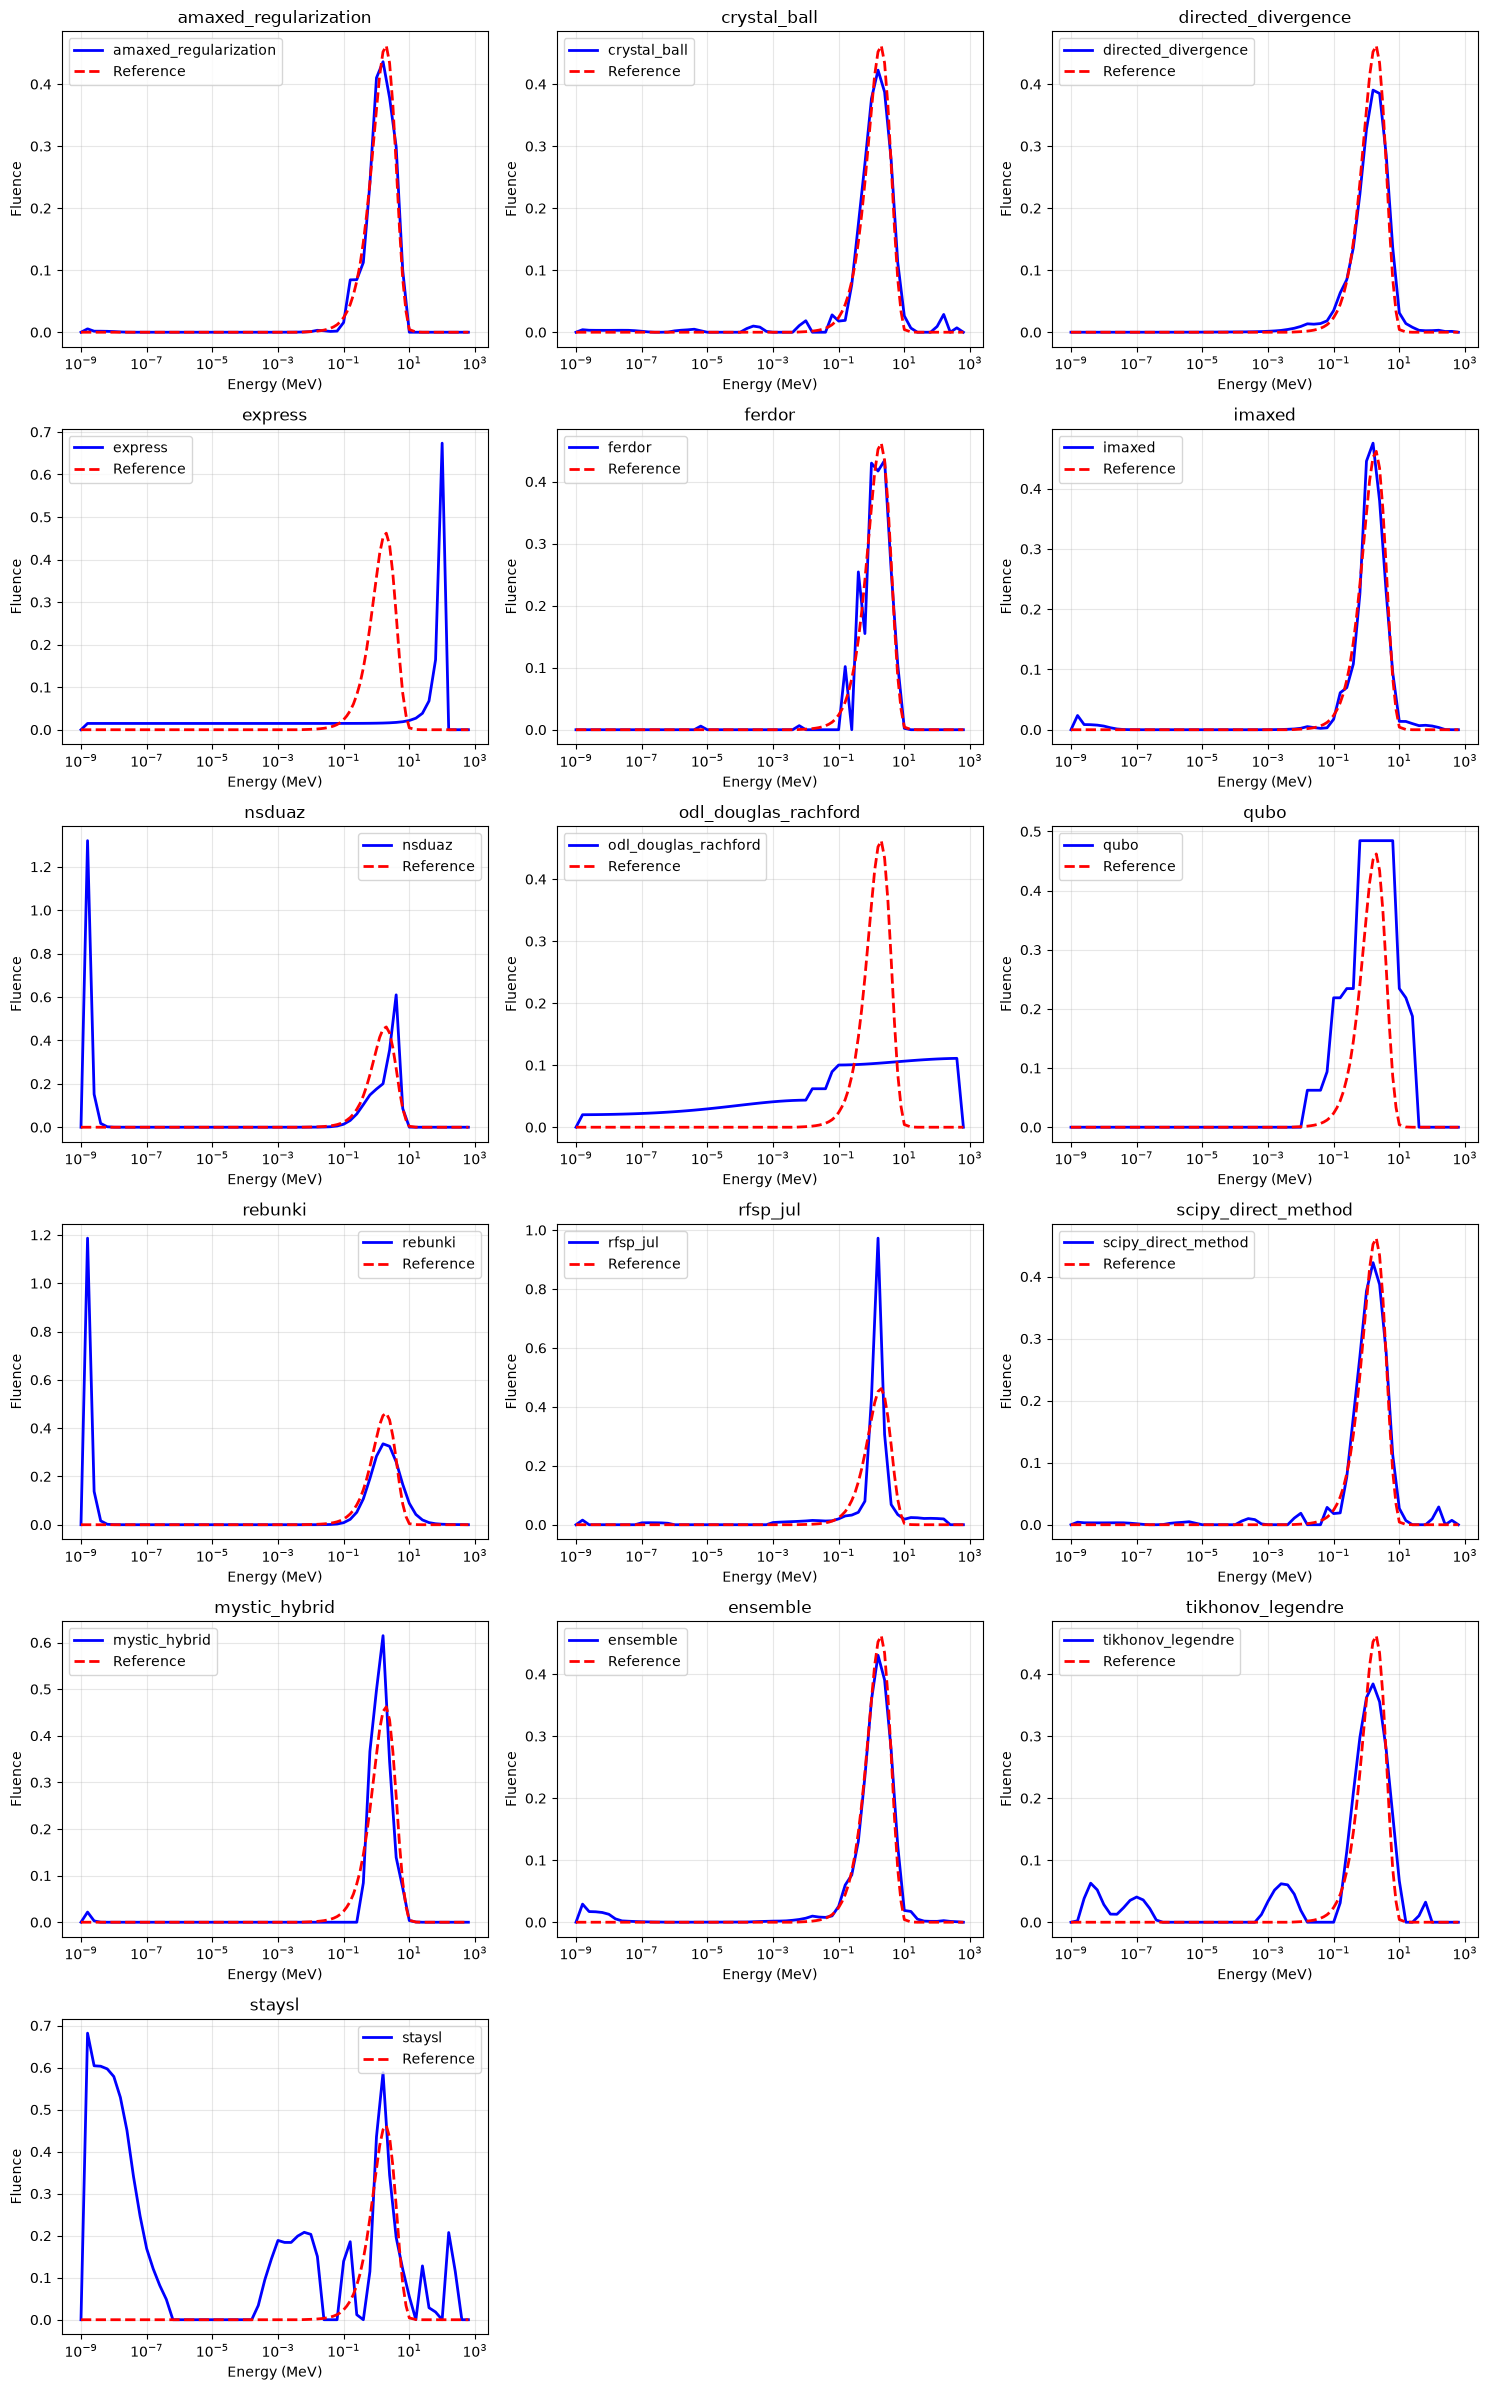

In [13]:
# Individual spectrum plots (one subplot per successful method)
names = list(ok_results.keys())
n = len(names)
if n:
    cols = 3
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, name in zip(axes, names):
        ax.plot(det.E_MeV, ok_results[name]['spectrum'], 'b-', label=name, linewidth=2)
        ax.plot(reference_spectrum['E_MeV'], reference_spectrum['ISO_ref_Cf252'],
                'r--', label='Reference', linewidth=2)
        ax.set_title(name)
        ax.set_xlabel('Energy (MeV)')
        ax.set_ylabel('Fluence')
        ax.set_xscale('log')
        ax.legend()
        ax.grid(True, alpha=0.3)
    for ax in axes[n:]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

## Summary

Each method without a dedicated notebook was imported and executed against the same detector readings. The table below summarises the outcome (method, status, reconstructed-spectrum maximum). Methods flagged `FAIL` typically need an optional dependency that is not installed in the current environment.

In [14]:
summary_rows = []
for name in RESULTS:
    status, payload = RESULTS[name]
    if status == 'ok':
        spec = np.asarray(payload['spectrum'])
        summary_rows.append({'method': name, 'status': 'ok', 'spectrum_max': float(spec.max())})
    else:
        summary_rows.append({'method': name, 'status': 'fail', 'spectrum_max': None, 'error': payload})

summary_df = pd.DataFrame(summary_rows).set_index('method')
summary_df

,status,spectrum_max
method,,
amaxed_regularization,ok,0.436063
crystal_ball,ok,0.422517
directed_divergence,ok,0.390327
express,ok,0.673563
ferdor,ok,0.434247
imaxed,ok,0.475544
nsduaz,ok,1.320297
odl_douglas_rachford,ok,0.111047
qubo,ok,0.484375
